In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


CUDA available: True
Device count: 1
Device name: Tesla P100-PCIE-16GB


In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image as IPyImage

from PIL import Image

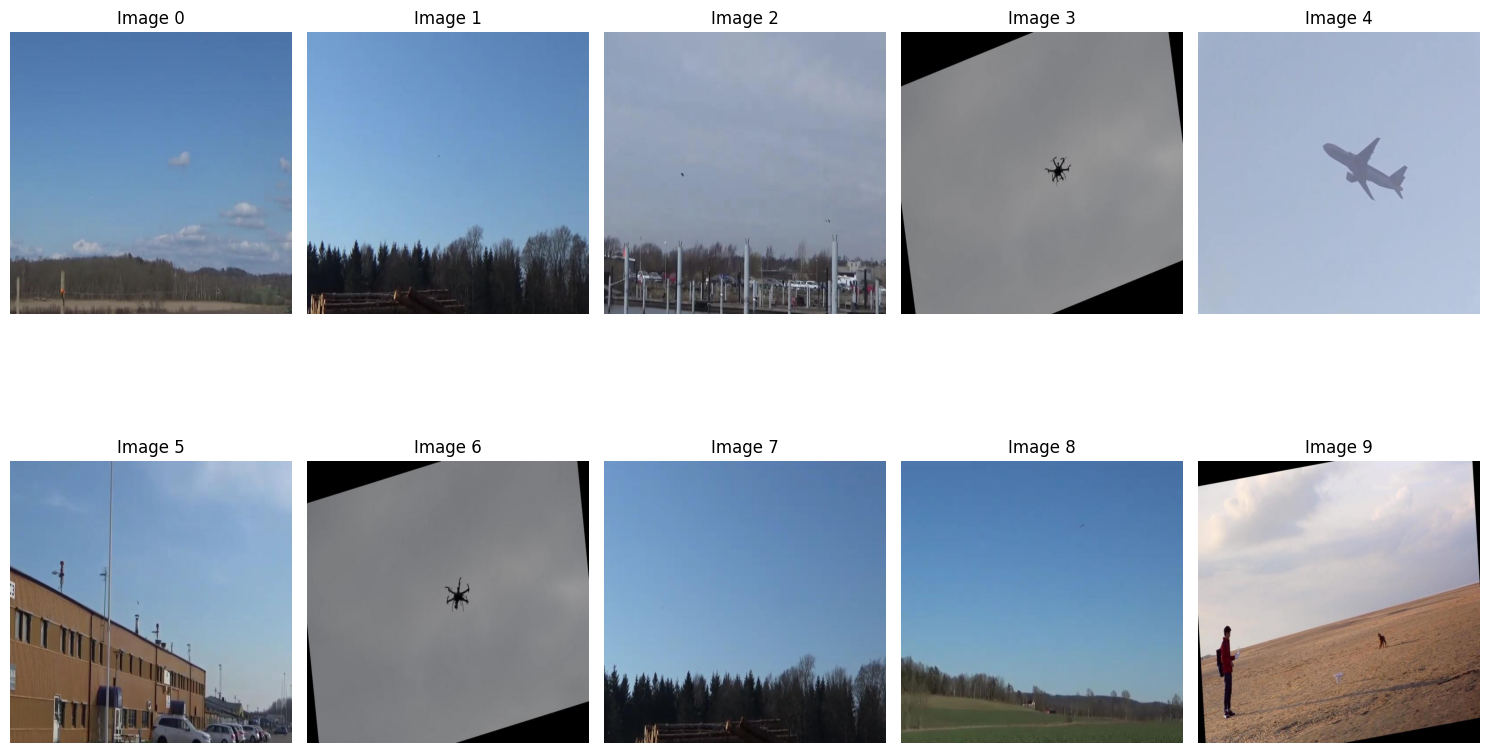

In [3]:

base_dir = '/kaggle/input/drone-detection-dataset/updated dataset'

image_files = [os.path.join(base_dir, 'train', 'images',x) for x in os.listdir(os.path.join(base_dir, 'train', 'images'))[:10]]
rows, cols = 2, 5
fig, axs = plt.subplots(rows, cols, figsize=(15, 10))

for i, ax in enumerate(axs.flat):
    if i<len(image_files):
        img = mpimg.imread(image_files[i])
        ax.imshow(img)
        ax.set_title(f"Image {i}")
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()    

In [ ]:
! pip install ultralytics
from ultralytics import YOLO

In [6]:
model = YOLO('yolo11s.pt') 

In [7]:
yaml_dir = os.path.join(base_dir, 'data.yaml')

results=model.train(
    data=yaml_dir,
    epochs=10,
    batch=32,
    imgsz=640,
    patience=5,              # Early stopping
    val=True,
    name="run_1",
    project="/kaggle/working/Dorne_detection_res",
    device='cuda',
    verbose=True,
    exist_ok=True,
    save=True
)

Ultralytics 8.3.201 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/drone-detection-dataset/updated dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=run_1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        765        741      0.913      0.906      0.945      0.583
              AirPlane        133        133      0.888      0.898      0.965      0.627
                 Drone        382        468      0.898      0.863      0.895       0.44
            Helicopter        140        140      0.953      0.957      0.975      0.682
Speed: 0.2ms preprocess, 4.6ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /kaggle/working/Dorne_detection_res/run_1


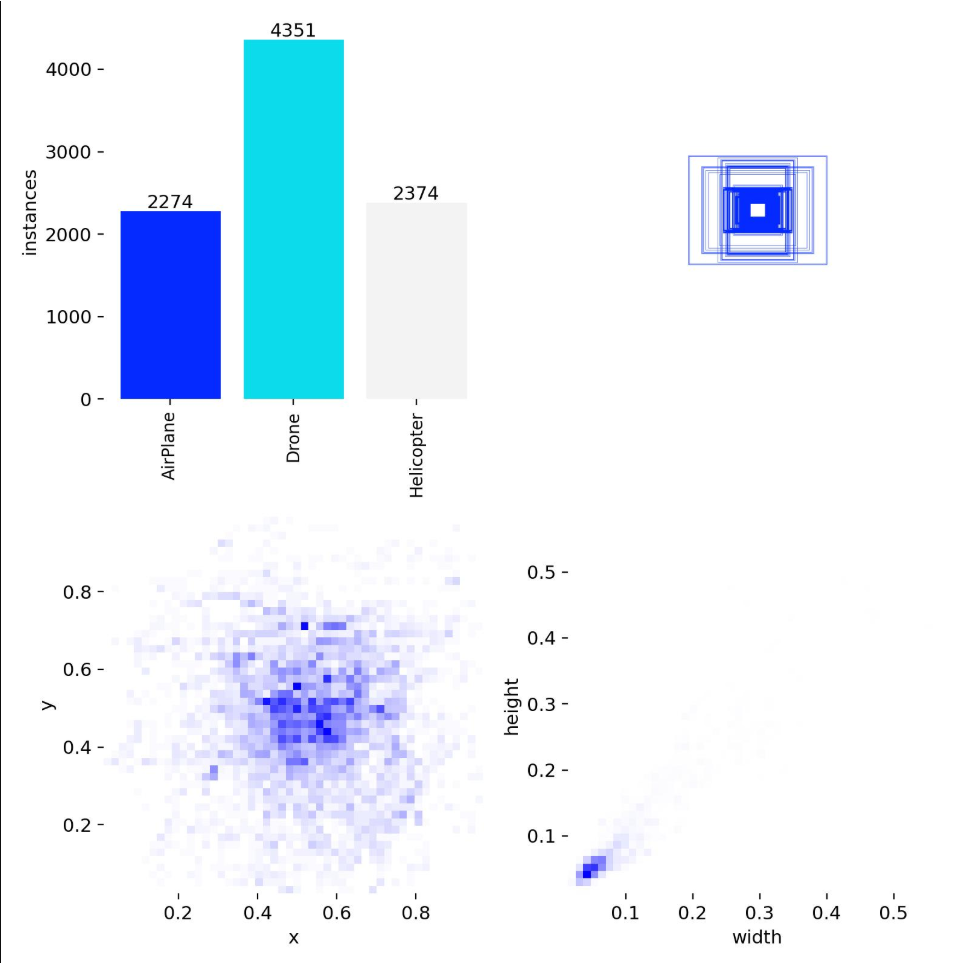

In [2]:
IPyImage(r'D:\Courses\AI work\Deep learning\Computer vision\NTI (summer Training)CV\NTI\final project\output\my_output (1)\Screenshot 2025-09-18 172522.png', width=600)


In [32]:
res=model.predict(
    source='/kaggle/input/test-data2/Screenshot 2025-09-16 201214.png',  # Replace with your test image path
    conf=0.36,        # Confidence threshold
    iou=0.45,        # IoU threshold
    save=True        # Saves annotated image to /kaggle/runs/detect/
)



image 1/1 /kaggle/input/test-data2/Screenshot 2025-09-16 201214.png: 384x640 1 AirPlane, 10.4ms
Speed: 2.1ms preprocess, 10.4ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /kaggle/working/Dorne_detection_res/run_1


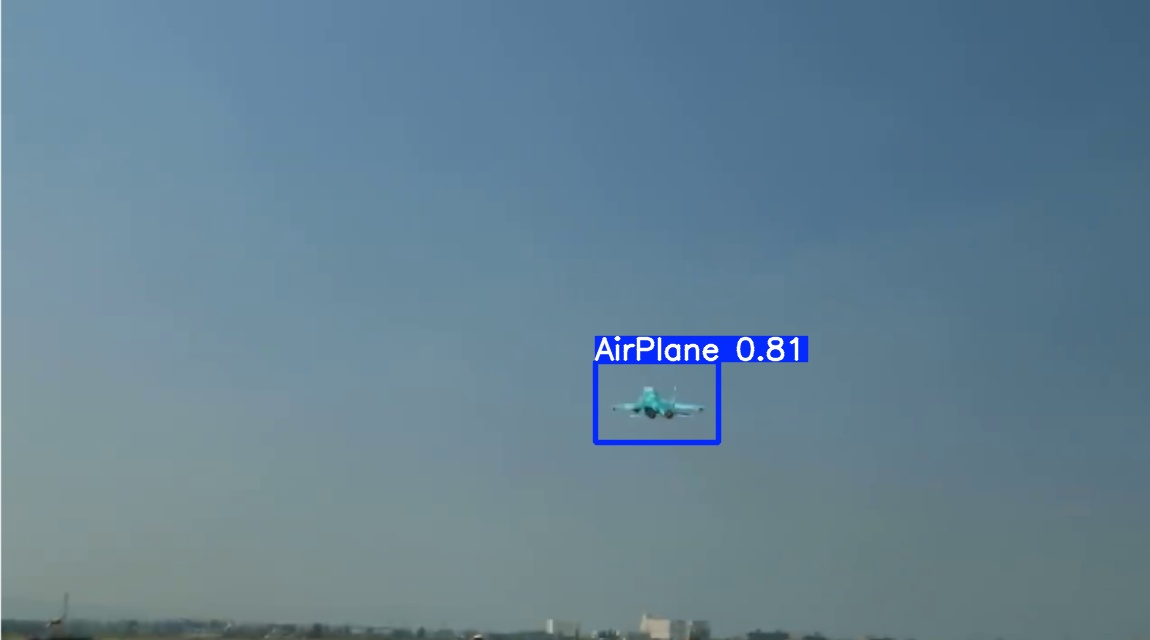

In [33]:
from IPython.display import Image as IPyImage
IPyImage('/kaggle/input/pretrained-model/run_1/results.png', width=600)
IPyImage('/kaggle/working/Dorne_detection_res/run_1/Screenshot 2025-09-16 201214.jpg', width=600)

In [ ]:
res = model.predict(
    source='/kaggle/input/test-datset/Recording 2025-09-17 172326.mp4',  # Path to your uploaded video
    save=True,                              # Saves output video with detections
    conf=0.5,
    iou=.45
)


In [40]:
from IPython.display import Video

Video('/kaggle/working/Dorne_detection_res/run_1/Recording 2025-09-17 172326.avi', width=600)


In [ ]:
# IPyImage('/kaggle/working/Dorne_detection_res/run_1/val_batch1_labels.jpg', width=600)
IPyImage('/kaggle/input/pretrained-model/run_1/val_batch0_pred.jpg', width=600)

In [ ]:
IPyImage('/kaggle/input/pretrained-model/run_1/val_batch1_pred.jpg', width=600)

## Extracting the output

In [50]:
import shutil
shutil.make_archive('/kaggle/working/my_output', 'zip', '/kaggle/working/')
from IPython.display import FileLink
FileLink('/kaggle/working/my_output.zip')

/kaggle/working/my_output.zip

## problem with Drone Class

In [ ]:
best_model_path = '/kaggle/input/pretrained-model/run_1/weights/best.pt' # Path to the best weights from training
best_model = YOLO(best_model_path)

best_model.conf = 0.5     
best_model.iou = 0.45

In [ ]:
metrics = best_model.val(data='/kaggle/input/drone-detection/drone-detection-new.v5-new-train.yolov8/data.yaml')
print(metrics)

In [ ]:
results = best_model.predict(
    source='/kaggle/input/test-data2/Screenshot 2025-09-16 185553.png',  # Replace with your test image path
    conf=0.48,        # Confidence threshold
    iou=0.45,        # IoU threshold
    save=True        # Saves annotated image to /kaggle/runs/detect/
)


In [ ]:
IPyImage('/kaggle/working/runs/detect/predict/Screenshot 2025-09-16 185553.jpg', width=600)